In [1]:
"""
Grid Search - Results & Visualization

Aggregates grid-search results and generates summary plots and reports.
"""
from google.colab import drive
drive.mount('/content/drive/')

import os
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, classification_report, f1_score

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Results root: /content/drive/MyDrive/authentic_training_cv_grid/model3
Data root: /content/drive/MyDrive/authentic_split_cv_tuning
Output dir: /content/drive/MyDrive/authentic_training_cv_grid/analysis_output_m3

Grid search summary (sorted by mean test accuracy):

 config_idx      lr  unfrozen_layers    dropout  mean_test_acc  std_test_acc  mean_val_acc
          6 0.00005               60 (0.3, 0.6)       0.842216      0.022380      0.886396
          7 0.00005               60 (0.4, 0.5)       0.837538      0.017773      0.878310
          2 0.00003               60 (0.3, 0.6)       0.803666      0.032245      0.873659
          3 0.00003               60 (0.4, 0.5)       0.800097      0.025391      0.862058
          5 0.00005               40 (0.4, 0.5)       0.794228      0.032606      0.879466
          4 0.00005               40 (0.3, 0.6)       0.775894      0.044146      0.870171
          0 0.00003               40 (0.3, 0.6)       0.774379      0.040026      0.864417
      

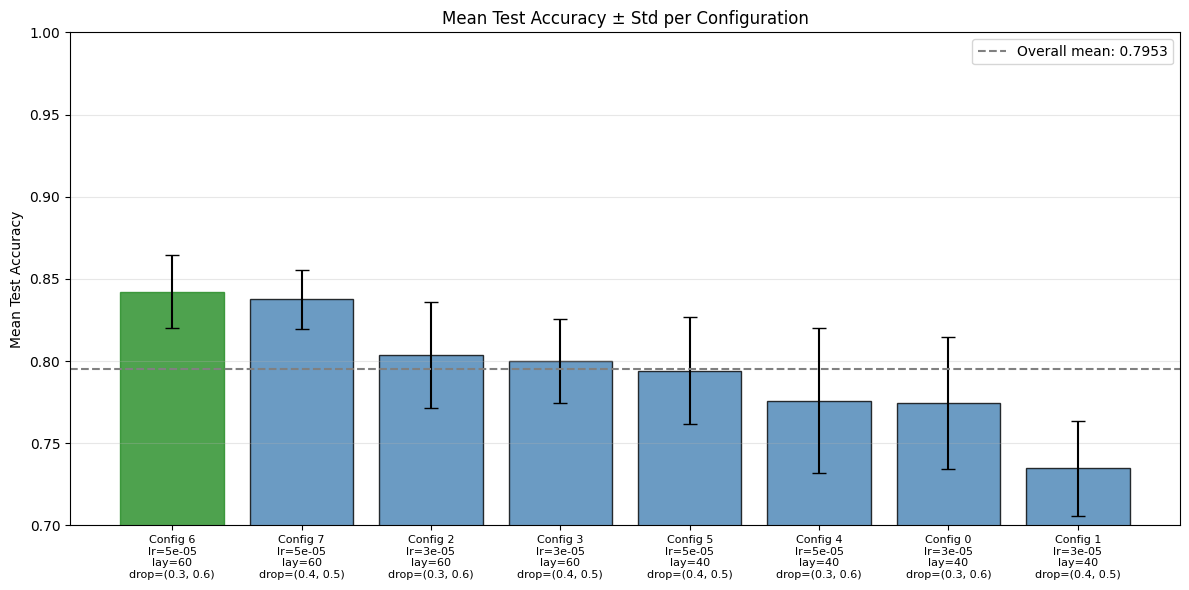

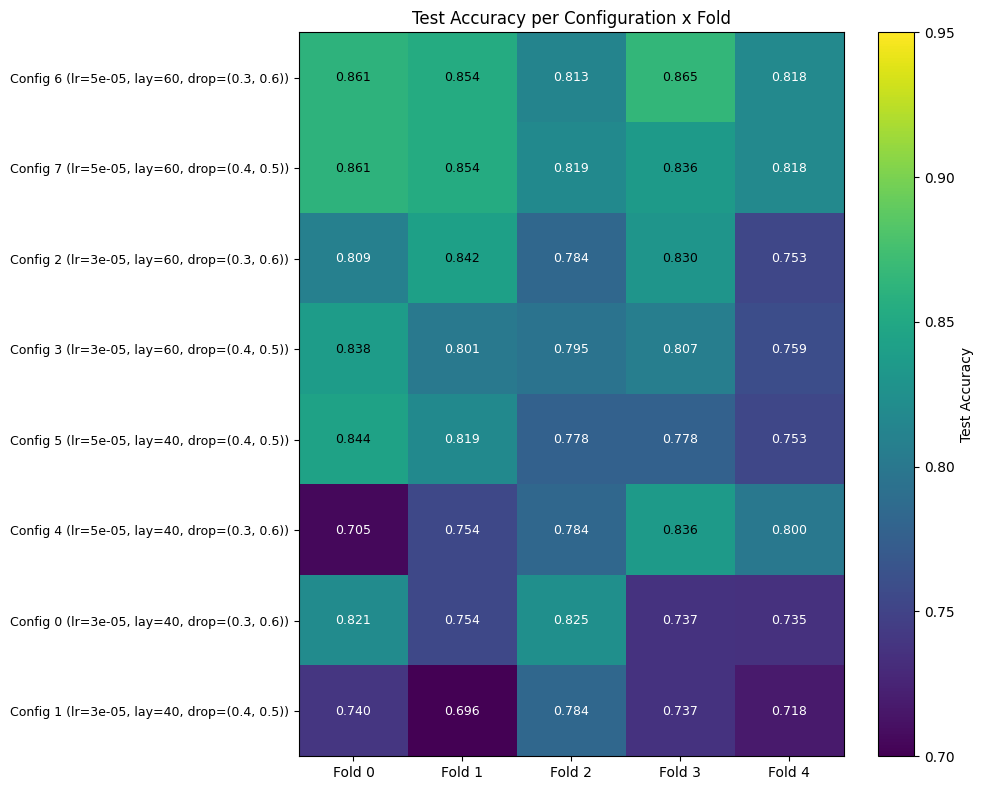

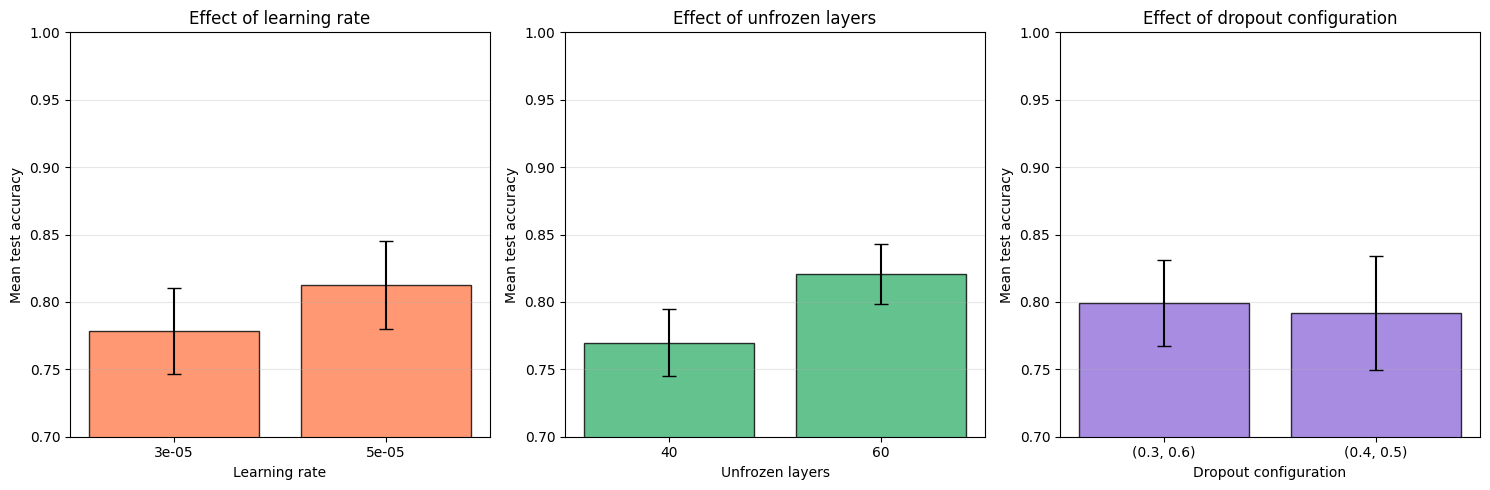

Saved metric-only plots.


In [2]:
# Paths
RESULTS_ROOT = Path("/content/drive/MyDrive/authentic_training_cv_grid/model3")
DATA_ROOT = Path("/content/drive/MyDrive/authentic_split_cv_tuning")
OUTPUT_DIR = Path("/content/drive/MyDrive/authentic_training_cv_grid/analysis_output_m3")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ["t72", "t80", "t90"]
NUM_FOLDS = 5

# Hyperparameter grid (reference)
HYPERPARAM_GRID = [
    {"lr": 3e-5, "unfrozen_layers": 40, "dropout": (0.3, 0.6)},
    {"lr": 3e-5, "unfrozen_layers": 40, "dropout": (0.4, 0.5)},
    {"lr": 3e-5, "unfrozen_layers": 60, "dropout": (0.3, 0.6)},
    {"lr": 3e-5, "unfrozen_layers": 60, "dropout": (0.4, 0.5)},
    {"lr": 5e-5, "unfrozen_layers": 40, "dropout": (0.3, 0.6)},
    {"lr": 5e-5, "unfrozen_layers": 40, "dropout": (0.4, 0.5)},
    {"lr": 5e-5, "unfrozen_layers": 60, "dropout": (0.3, 0.6)},
    {"lr": 5e-5, "unfrozen_layers": 60, "dropout": (0.4, 0.5)},
]

print(f"Results root: {RESULTS_ROOT}")
print(f"Data root: {DATA_ROOT}")
print(f"Output dir: {OUTPUT_DIR}")


def aggregate_results():
    """Read results.json from each config folder and build a DataFrame."""
    all_results = []

    for config_idx, config in enumerate(HYPERPARAM_GRID):
        lr = config["lr"]
        layers = config["unfrozen_layers"]
        d1, d2 = config["dropout"]
        config_name = f"config_{config_idx}_lr{lr:.0e}_lay{layers}_drop{d1}_{d2}".replace(".", "p")

        results_path = RESULTS_ROOT / config_name / "results.json"
        if not results_path.exists():
            print(f"Warning: missing results for config {config_idx}: {results_path}")
            continue

        with open(results_path, "r") as f:
            cfg_results = json.load(f)

        test_accs = [cfg_results[f"fold_{i}"]["test_accuracy"] for i in range(NUM_FOLDS)]
        val_accs = [cfg_results[f"fold_{i}"]["best_val_accuracy"] for i in range(NUM_FOLDS)]
        test_losses = [cfg_results[f"fold_{i}"]["test_loss"] for i in range(NUM_FOLDS)]
        epochs = [cfg_results[f"fold_{i}"]["epochs_trained"] for i in range(NUM_FOLDS)]

        all_results.append({
            "config_idx": config_idx,
            "config_name": config_name,
            "lr": lr,
            "unfrozen_layers": layers,
            "dropout": f"({d1}, {d2})",
            **{f"fold_{i}_test": test_accs[i] for i in range(NUM_FOLDS)},
            "mean_test_acc": np.mean(test_accs),
            "std_test_acc": np.std(test_accs),
            "mean_val_acc": np.mean(val_accs),
            "std_val_acc": np.std(val_accs),
            "mean_test_loss": np.mean(test_losses),
            "mean_epochs": np.mean(epochs),
        })

    return pd.DataFrame(all_results)


df = aggregate_results()
df_sorted = df.sort_values("mean_test_acc", ascending=False).reset_index(drop=True)

# Aggregate and summarize
print("\nGrid search summary (sorted by mean test accuracy):\n")
display_cols = [
    "config_idx", "lr", "unfrozen_layers", "dropout",
    "mean_test_acc", "std_test_acc", "mean_val_acc",
]
print(df_sorted[display_cols].to_string(index=False))

# Save summary
summary_path = OUTPUT_DIR / "grid_search_summary.csv"
df_sorted.to_csv(summary_path, index=False)
print(f"Saved grid search summary to: {summary_path}")

# PLOT 1: Mean accuracy per config
fig, ax = plt.subplots(figsize=(12, 6))
x_pos = np.arange(len(df_sorted))
labels = [f"Config {row['config_idx']}\nlr={row['lr']:.0e}\nlay={row['unfrozen_layers']}\ndrop={row['dropout']}"
          for _, row in df_sorted.iterrows()]

bars = ax.bar(x_pos, df_sorted["mean_test_acc"], yerr=df_sorted["std_test_acc"],
              capsize=5, color="steelblue", edgecolor="black", alpha=0.8)
if len(bars) > 0:
    bars[0].set_color("forestgreen")  # Winner is first after sort

ax.set_xticks(x_pos)
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("Mean Test Accuracy")
ax.set_title("Mean Test Accuracy ± Std per Configuration")
ax.set_ylim(0.7, 1.0)
ax.axhline(df_sorted["mean_test_acc"].mean(), linestyle="--", color="gray",
           label=f"Overall mean: {df_sorted['mean_test_acc'].mean():.4f}")
ax.grid(axis="y", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_mean_acc_per_config.png", dpi=150)
plt.show()

# PLOT 2: Accuracy heatmap (Config x Fold)
fold_cols = [f"fold_{i}_test" for i in range(NUM_FOLDS)]
data = df_sorted[fold_cols].values

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(data, cmap="viridis", aspect="auto", vmin=0.7, vmax=0.95)
ax.set_xticks(range(NUM_FOLDS))
ax.set_xticklabels([f"Fold {i}" for i in range(NUM_FOLDS)])
ax.set_yticks(range(len(df_sorted)))
ax.set_yticklabels([f"Config {row['config_idx']} (lr={row['lr']:.0e}, lay={row['unfrozen_layers']}, drop={row['dropout']})"
                    for _, row in df_sorted.iterrows()], fontsize=9)

for i in range(len(df_sorted)):
    for j in range(NUM_FOLDS):
        color = "white" if data[i, j] < 0.83 else "black"
        ax.text(j, i, f"{data[i, j]:.3f}", ha="center", va="center", color=color, fontsize=9)

ax.set_title("Test Accuracy per Configuration x Fold")
plt.colorbar(im, ax=ax, label="Test Accuracy")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_accuracy_heatmap.png", dpi=150)
plt.show()

# PLOT 3: Hyperparameter marginal effects
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

dimensions = [
    ("lr", "Learning rate", "coral", lambda v: f"{v:.0e}"),
    ("unfrozen_layers", "Unfrozen layers", "mediumseagreen", str),
    ("dropout", "Dropout configuration", "mediumpurple", str),
]

for ax, (col, title, color, fmt) in zip(axes, dimensions):
    groups = df.groupby(col).agg(
        mean=("mean_test_acc", "mean"),
        std=("mean_test_acc", "std"),
    ).reset_index()

    ax.bar(
        range(len(groups)), groups["mean"], yerr=groups["std"],
        capsize=5, color=color, edgecolor="black", alpha=0.8,
    )
    ax.set_xticks(range(len(groups)))
    ax.set_xticklabels([fmt(v) for v in groups[col]])
    ax.set_xlabel(title)
    ax.set_ylabel("Mean test accuracy")
    ax.set_title(f"Effect of {title.lower()}")
    ax.set_ylim(0.7, 1.0)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_hyperparameter_effects.png", dpi=150)
plt.show()

print("Saved metric-only plots.")

  Config 6, Fold 0... Found 173 files belonging to 3 classes.
done
  Config 6, Fold 1... Found 171 files belonging to 3 classes.
done
  Config 6, Fold 2... Found 171 files belonging to 3 classes.
done
  Config 6, Fold 3... Found 171 files belonging to 3 classes.
done
  Config 6, Fold 4... Found 170 files belonging to 3 classes.
done
  Config 7, Fold 0... Found 173 files belonging to 3 classes.
done
  Config 7, Fold 1... Found 171 files belonging to 3 classes.
done
  Config 7, Fold 2... Found 171 files belonging to 3 classes.
done
  Config 7, Fold 3... Found 171 files belonging to 3 classes.
done
  Config 7, Fold 4... Found 170 files belonging to 3 classes.
done
  Config 2, Fold 0... Found 173 files belonging to 3 classes.
done
  Config 2, Fold 1... Found 171 files belonging to 3 classes.
done
  Config 2, Fold 2... Found 171 files belonging to 3 classes.
done
  Config 2, Fold 3... Found 171 files belonging to 3 classes.
done
  Config 2, Fold 4... Found 170 files belonging to 3 classes.


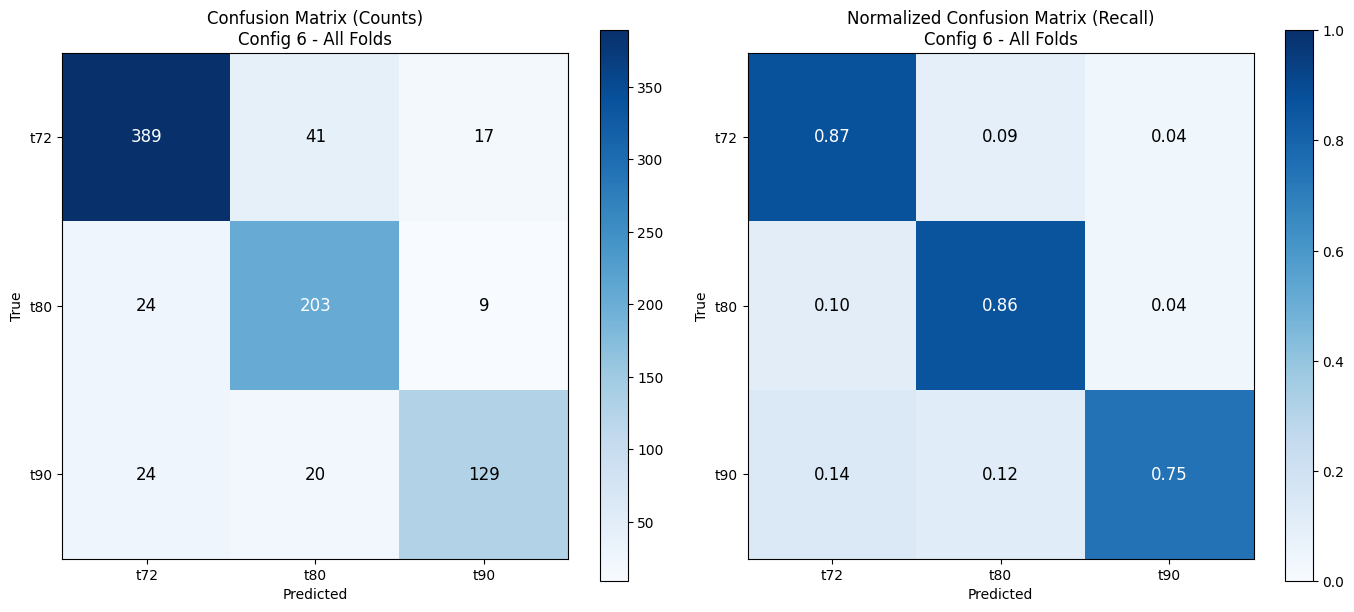

Saved winner confusion matrices to: /content/drive/MyDrive/authentic_training_cv_grid/analysis_output_m3/04_winner_confusion_matrices.png


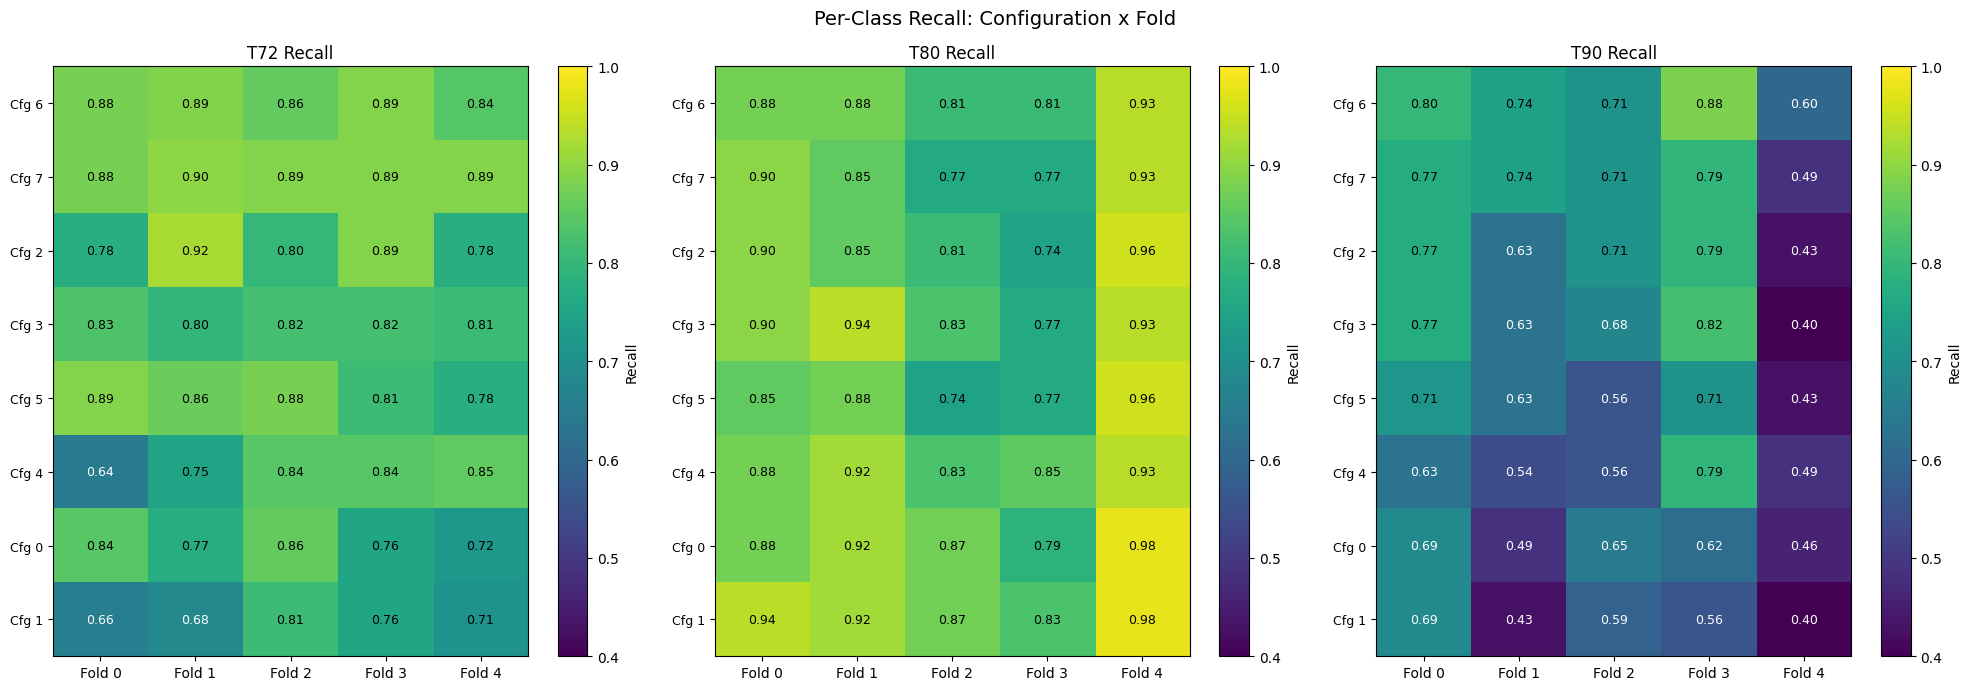

Saved per-class recall plots to: /content/drive/MyDrive/authentic_training_cv_grid/analysis_output_m3/05_per_class_recall.png


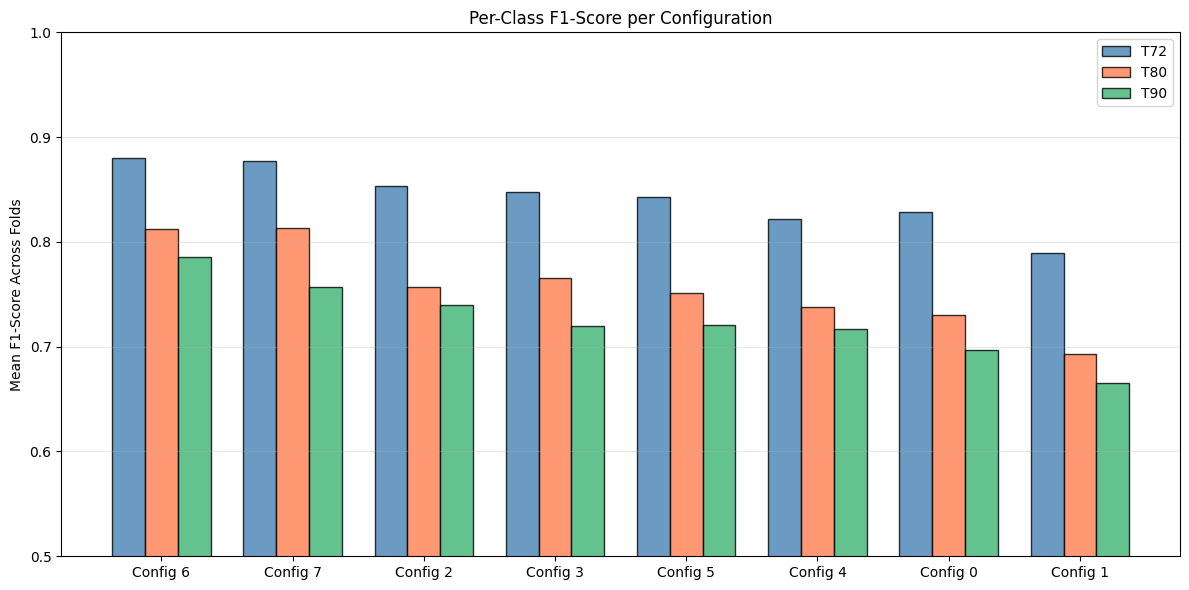

Saved per-class F1 plot to: /content/drive/MyDrive/authentic_training_cv_grid/analysis_output_m3/06_per_class_f1.png


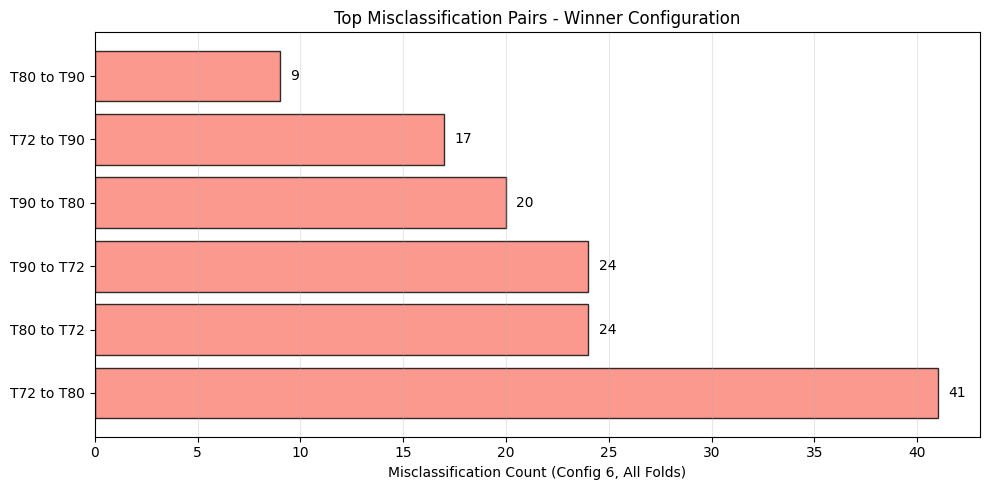

Saved top misclassification plot to: /content/drive/MyDrive/authentic_training_cv_grid/analysis_output_m3/07_top_misclassifications.png
Grid search winner report

Winner: Config 6
Learning rate: 5e-05
Unfrozen layers: 60
Dropout: (0.3, 0.6)

Mean test acc: 0.8422 ± 0.0224
Mean val acc: 0.8864

Per-fold test accuracies:
  Fold 0: 0.8613
  Fold 1: 0.8538
  Fold 2: 0.8129
  Fold 3: 0.8655
  Fold 4: 0.8176

Aggregated classification report (all folds combined):
              precision    recall  f1-score   support

         t72     0.8902    0.8702    0.8801       447
         t80     0.7689    0.8602    0.8120       236
         t90     0.8323    0.7457    0.7866       173

    accuracy                         0.8423       856
   macro avg     0.8305    0.8254    0.8262       856
weighted avg     0.8450    0.8423    0.8424       856

Saved winner report to: /content/drive/MyDrive/authentic_training_cv_grid/analysis_output_m3/winner_report.txt


In [4]:
# Compute confusion matrices and detailed analyses

def compute_confusion_matrices(df):
    """Load fold models and compute confusion matrices on test sets."""
    img_size = (682, 1024)
    batch_size = 4

    cm_data = {}
    predictions_data = {}

    for _, row in df.iterrows():
        config_idx = int(row["config_idx"])
        config_name = row["config_name"]

        cm_data[config_idx] = {}
        predictions_data[config_idx] = {}

        for fold_idx in range(NUM_FOLDS):
            model_path = RESULTS_ROOT / config_name / f"model_fold{fold_idx}.keras"
            test_dir = DATA_ROOT / f"fold_{fold_idx}" / "test"

            if not model_path.exists():
                print(f"Warning: missing model {model_path}")
                continue
            if not test_dir.exists():
                print(f"Warning: missing test data {test_dir}")
                continue

            print(f"  Config {config_idx}, Fold {fold_idx}...", end=" ")

            model = keras.models.load_model(model_path)

            test_ds = keras.utils.image_dataset_from_directory(
                test_dir, labels="inferred", label_mode="int",
                image_size=img_size, batch_size=batch_size, shuffle=False,
                crop_to_aspect_ratio=True,
            )

            y_true = []
            y_pred = []
            for batch_imgs, batch_labels in test_ds:
                preds = model.predict(batch_imgs, verbose=0)
                y_pred.extend(np.argmax(preds, axis=1))
                y_true.extend(batch_labels.numpy())

            cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
            cm_data[config_idx][fold_idx] = cm
            predictions_data[config_idx][fold_idx] = (y_true, y_pred)
            print("done")

            del model
            keras.backend.clear_session()

    return cm_data, predictions_data



cm_data, predictions_data = compute_confusion_matrices(df_sorted)

winner_idx = int(df_sorted.iloc[0]["config_idx"])

# Winner confusion matrices
cm_sum = sum(cm_data[winner_idx].values())
cm_normalized = cm_sum.astype(float) / cm_sum.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im1 = axes[0].imshow(cm_sum, cmap="Blues")
axes[0].set_xticks(range(3)); axes[0].set_xticklabels(CLASS_NAMES)
axes[0].set_yticks(range(3)); axes[0].set_yticklabels(CLASS_NAMES)
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
axes[0].set_title(f"Confusion Matrix (Counts)\nConfig {winner_idx} - All Folds")
for i in range(3):
    for j in range(3):
        color = "white" if cm_sum[i, j] > cm_sum.max() / 2 else "black"
        axes[0].text(j, i, str(cm_sum[i, j]), ha="center", va="center", color=color, fontsize=12)
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(cm_normalized, cmap="Blues", vmin=0, vmax=1)
axes[1].set_xticks(range(3)); axes[1].set_xticklabels(CLASS_NAMES)
axes[1].set_yticks(range(3)); axes[1].set_yticklabels(CLASS_NAMES)
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
axes[1].set_title(f"Normalized Confusion Matrix (Recall)\nConfig {winner_idx} - All Folds")
for i in range(3):
    for j in range(3):
        color = "white" if cm_normalized[i, j] > 0.5 else "black"
        axes[1].text(j, i, f"{cm_normalized[i, j]:.2f}", ha="center", va="center", color=color, fontsize=12)
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_winner_confusion_matrices.png", dpi=150)
plt.show()
print(f"Saved winner confusion matrices to: {OUTPUT_DIR / '04_winner_confusion_matrices.png'}")

# Per-class recall heatmaps: config x fold, one subplot per class.
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for class_idx, class_name in enumerate(CLASS_NAMES):
    recall_data = np.zeros((len(df_sorted), NUM_FOLDS))

    for i, (_, row) in enumerate(df_sorted.iterrows()):
        cfg_idx = int(row["config_idx"])
        if cfg_idx not in cm_data:
            continue
        for fold_idx in range(NUM_FOLDS):
            if fold_idx not in cm_data[cfg_idx]:
                continue
            cm = cm_data[cfg_idx][fold_idx]
            row_sum = cm[class_idx].sum()
            recall_data[i, fold_idx] = cm[class_idx, class_idx] / row_sum if row_sum > 0 else 0

    im = axes[class_idx].imshow(recall_data, cmap="viridis", vmin=0.4, vmax=1.0, aspect="auto")
    axes[class_idx].set_xticks(range(NUM_FOLDS))
    axes[class_idx].set_xticklabels([f"Fold {i}" for i in range(NUM_FOLDS)])
    axes[class_idx].set_yticks(range(len(df_sorted)))
    axes[class_idx].set_yticklabels([f"Cfg {row['config_idx']}" for _, row in df_sorted.iterrows()], fontsize=9)
    axes[class_idx].set_title(f"{class_name.upper()} Recall")

    for i in range(len(df_sorted)):
        for j in range(NUM_FOLDS):
            color = "white" if recall_data[i, j] < 0.7 else "black"
            axes[class_idx].text(j, i, f"{recall_data[i, j]:.2f}",
                                 ha="center", va="center", color=color, fontsize=9)

    plt.colorbar(im, ax=axes[class_idx], label="Recall")

plt.suptitle("Per-Class Recall: Configuration x Fold", fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "05_per_class_recall.png", dpi=150)
plt.show()
print(f"Saved per-class recall plots to: {OUTPUT_DIR / '05_per_class_recall.png'}")

# Per-class mean F1 across folds, grouped by configuration.
f1_data = {cls: [] for cls in CLASS_NAMES}
config_ids = []

for _, row in df_sorted.iterrows():
    cfg_idx = int(row["config_idx"])
    if cfg_idx not in predictions_data:
        continue
    config_ids.append(cfg_idx)

    fold_f1s = {cls: [] for cls in CLASS_NAMES}
    for fold_idx in range(NUM_FOLDS):
        if fold_idx not in predictions_data[cfg_idx]:
            continue
        y_true, y_pred = predictions_data[cfg_idx][fold_idx]
        f1_per_class = f1_score(y_true, y_pred, average=None, labels=[0, 1, 2], zero_division=0)
        for i, cls in enumerate(CLASS_NAMES):
            fold_f1s[cls].append(f1_per_class[i])

    for cls in CLASS_NAMES:
        f1_data[cls].append(np.mean(fold_f1s[cls]) if fold_f1s[cls] else 0)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(config_ids))
width = 0.25
colors = {"t72": "steelblue", "t80": "coral", "t90": "mediumseagreen"}
for i, cls in enumerate(CLASS_NAMES):
    offset = (i - 1) * width
    ax.bar(x + offset, f1_data[cls], width, label=cls.upper(), color=colors[cls], edgecolor="black", alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels([f"Config {cid}" for cid in config_ids])
ax.set_ylabel("Mean F1-Score Across Folds")
ax.set_title("Per-Class F1-Score per Configuration")
ax.set_ylim(0.5, 1.0)
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "06_per_class_f1.png", dpi=150)
plt.show()
print(f"Saved per-class F1 plot to: {OUTPUT_DIR / '06_per_class_f1.png'}")

# Top misclassifications for winner
errors = {
    f"{CLASS_NAMES[i].upper()} to {CLASS_NAMES[j].upper()}": int(cm_sum[i, j])
    for i in range(3) for j in range(3) if i != j
}

sorted_errors = dict(sorted(errors.items(), key=lambda x: -x[1]))

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(list(sorted_errors.keys()), list(sorted_errors.values()),
        color="salmon", edgecolor="black", alpha=0.8)
ax.set_xlabel(f"Misclassification Count (Config {winner_idx}, All Folds)")
ax.set_title("Top Misclassification Pairs - Winner Configuration")
ax.grid(axis="x", alpha=0.3)

for i, (key, val) in enumerate(sorted_errors.items()):
    ax.text(val + 0.5, i, str(val), va="center", fontsize=10)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "07_top_misclassifications.png", dpi=150)
plt.show()
print(f"Saved top misclassification plot to: {OUTPUT_DIR / '07_top_misclassifications.png'}")

# Winner report
winner = df_sorted.iloc[0]
report_lines = [
    "Grid search winner report",
    "",
    f"Winner: Config {int(winner['config_idx'])}",
    f"Learning rate: {winner['lr']}",
    f"Unfrozen layers: {int(winner['unfrozen_layers'])}",
    f"Dropout: {winner['dropout']}",
    "",
    f"Mean test acc: {winner['mean_test_acc']:.4f} ± {winner['std_test_acc']:.4f}",
    f"Mean val acc: {winner['mean_val_acc']:.4f}",
    "",
    "Per-fold test accuracies:",
]
for i in range(NUM_FOLDS):
    report_lines.append(f"  Fold {i}: {winner[f'fold_{i}_test']:.4f}")

# Aggregated classification report
winner_idx = int(winner['config_idx'])
if winner_idx in predictions_data:
    all_y_true = []
    all_y_pred = []
    for fold_idx in range(NUM_FOLDS):
        if fold_idx in predictions_data[winner_idx]:
            y_true, y_pred = predictions_data[winner_idx][fold_idx]
            all_y_true.extend(y_true)
            all_y_pred.extend(y_pred)

    report_lines.append("")
    report_lines.append("Aggregated classification report (all folds combined):")
    report_lines.append(classification_report(all_y_true, all_y_pred,
                                              target_names=CLASS_NAMES, digits=4, zero_division=0))

report_text = "\n".join(report_lines)
print(report_text)

report_path = OUTPUT_DIR / "winner_report.txt"
with open(report_path, "w") as f:
    f.write(report_text)
print(f"Saved winner report to: {report_path}")